<a href="https://colab.research.google.com/github/ChiriKamau/soma/blob/main/notebooks/soma_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mapping and Analyzing the Impact of Schools at County Level

I come from **Nyandarua**, a county in central Kenya. Since I was in high school, I have known that Nyandarua has always been disadvantaged in education compared to our neighboring counties such as **Nyeri, Murang’a, or Kiambu**.  

The difference becomes clear when you look at the school infrastructure. Nyandarua has only **two National Schools**, very few Extra County schools, and—most significantly—**no university** within the county. For many students, this means traveling far away from home for higher education or missing out altogether.  

This personal experience motivated me to focus my project on **analyzing the impact of schools on education levels at the county level**. My aim is not only to show how the presence (or absence) of schools relates to educational outcomes but also to highlight **which counties across Kenya might need more investment in school infrastructure**.  

While working on this project, I also realized another important issue: the **migration of educated people**. Students often move to where universities and colleges are located, and many end up staying in those counties afterward. This means that counties without higher education institutions not only lose potential students but also struggle to attract skilled professionals in the long run.  

By analyzing these patterns systematically, I hope this project can contribute to understanding how **school distribution shapes education levels and long-term opportunities** in Kenya—and why counties like Nyandarua need urgent attention.


In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# school attendanc data

In [119]:
# Go to /content to avoid path issues
%cd /content
!rm -rf soma
!git clone https://github.com/ChiriKamau/soma.git
%cd soma


/content
Cloning into 'soma'...
remote: Enumerating objects: 524, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 524 (delta 3), reused 9 (delta 3), pack-reused 514 (from 1)
Receiving objects: 100% (524/524), 18.74 MiB | 31.62 MiB/s, done.
Resolving deltas: 100% (304/304), done.
/content/soma


In [120]:
import sys
sys.path.insert(0, '/content/soma')  # parent folder of fynesse


In [121]:
import importlib
from fynesse import access, assess, address

importlib.reload(access)
importlib.reload(assess)
importlib.reload(address)

<module 'fynesse.address' from '/content/soma/fynesse/address.py'>

In [122]:
from fynesse.access import attendance_acs, population_acs, education_acs, schools_acs, secondary_acs, univ_tvet_acs
from fynesse.assess import attendance_ass, population_ass, education_ass, schools_ass, secondary_ass, univ_tvet_ass, combine_correlation_data, prepare_regression_data, run_tvet_regression, regression2_ass, probability_ass, regression2_pop_normalized_ass, extract_higher_ed_info_with_population
from fynesse.address import attendance_add, population_add, population_vs_attendance, education_add, schools_add, secondary_add, univ_tvet_add, correlation_add, regression_add, tvet_regression_add, regression2_add, probability_add, regression2_pop_normalized_add


# SCHOOL ATTENDANCE PER COUNTY
This data I got from the Open Africa Data set and was in CSV format. There I had to clean it manually since it had some inconsistency in naming. From it I wanted to extract the number of students per sub-county initially, but due to lack of other sub-county data I settled for county level."

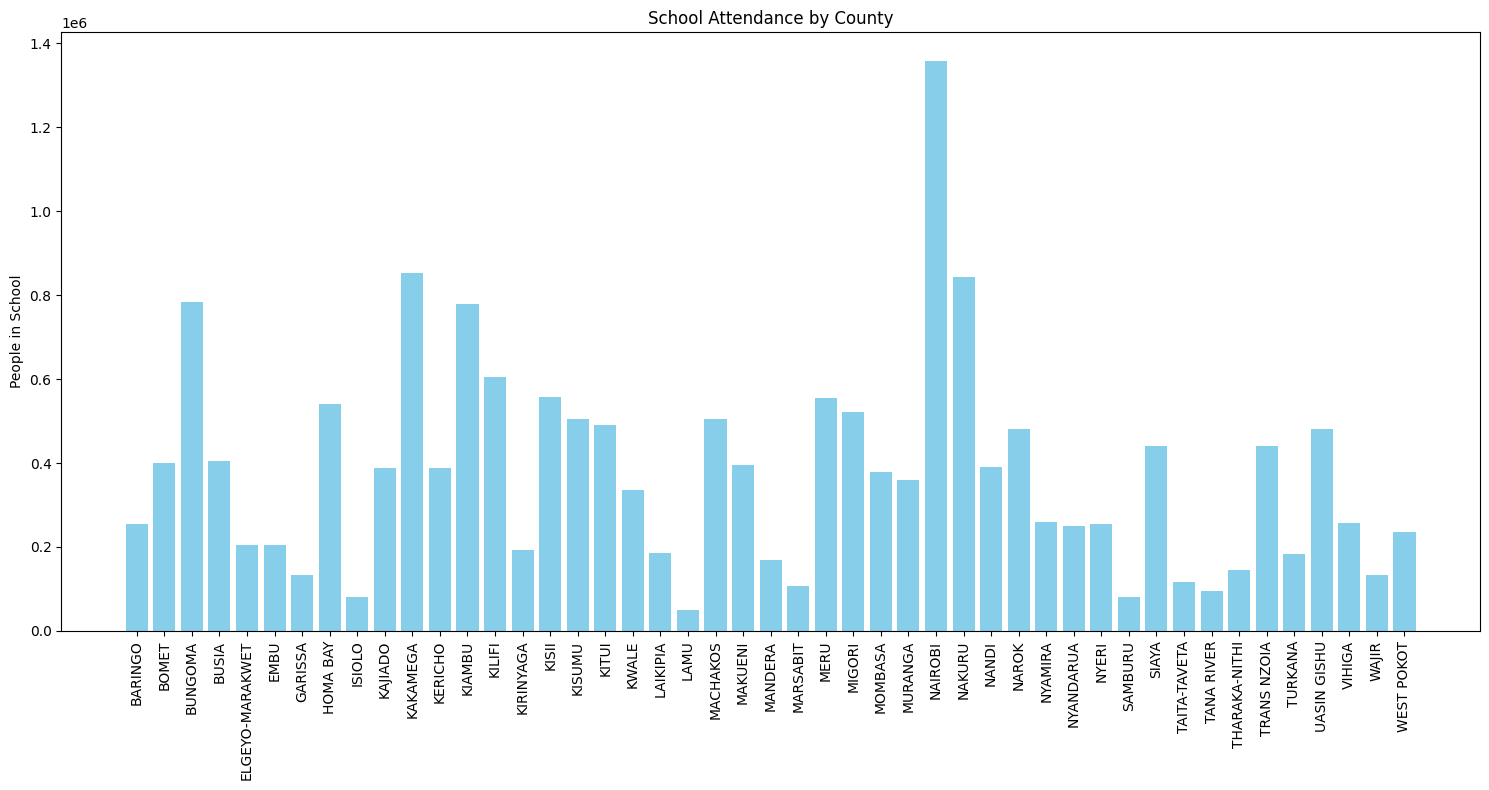

In [123]:

# Usage
url = "https://raw.githubusercontent.com/ChiriKamau/soma/main/data/distribution-of-population-age-3-years-and-above-by-school-attendance-status-area-of-residence-s.csv"

df_raw = attendance_acs(url)
county_data, area_col, school_col = attendance_ass(df_raw)
attendance_add(county_data, area_col, school_col)


This bar chart shows school attendance (number of people in school) across all 47 Kenyan counties. Nairobi has the highest attendance at about 1.36 million students, followed by Kiambu (~860,000) and Nakuru (~850,000). Most counties have between 200,000-600,000 students, while some smaller counties like Lamu and Isiolo have under 100,000. The variation reflects differences in population size and urbanization across counties.

# POPULATION BY AGE
Also this data I got from Open Africa Datasets. The key reason for me to use it is to try and compare with the data of students to see if they correlate. My assumption was that population in school are from the age of 4 to 20. This data can figure out where there are high dropouts or young people are not in school."

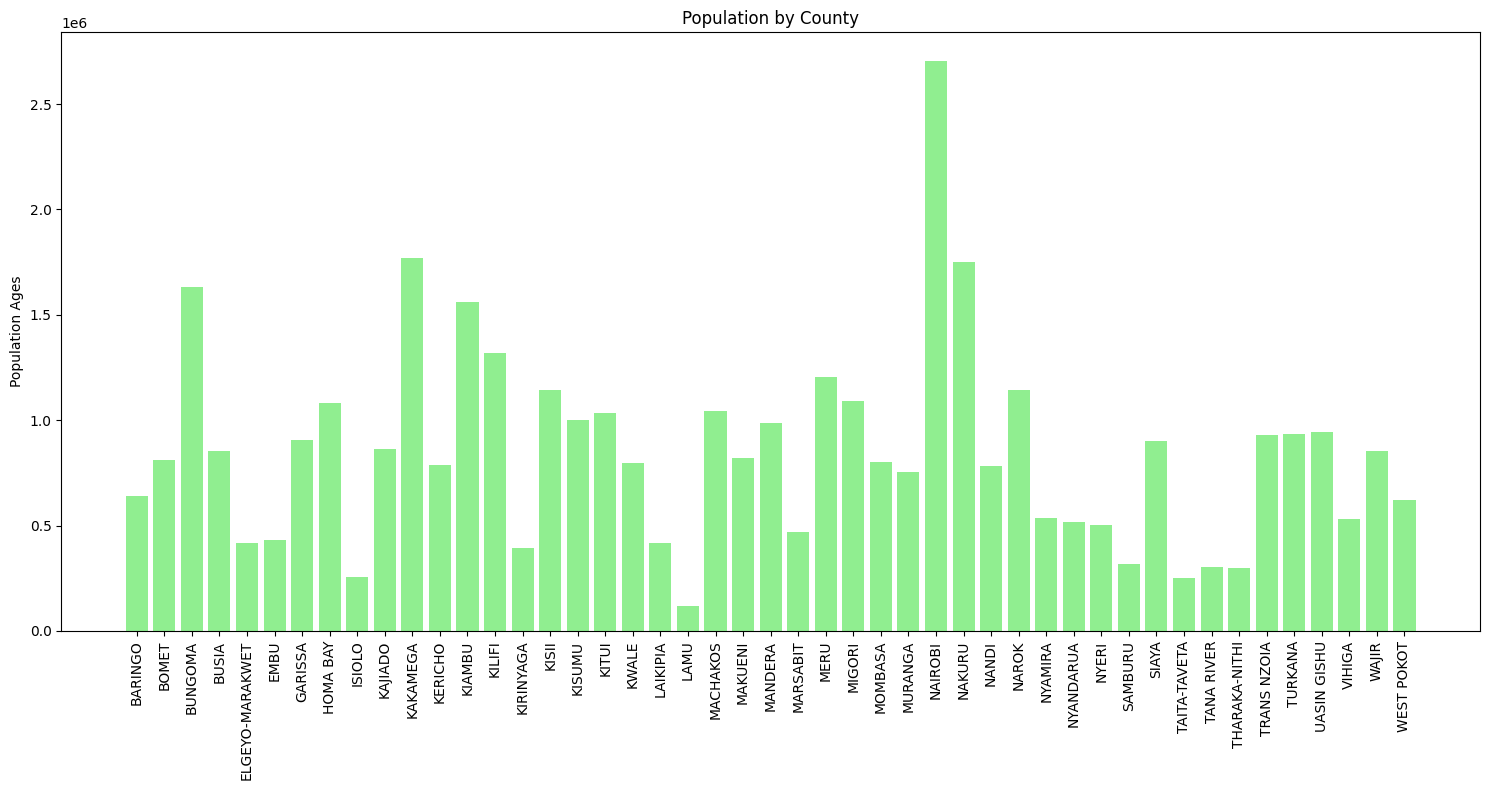

In [124]:

url_pop = "https://raw.githubusercontent.com/ChiriKamau/soma/main/data/Population_scounty_age_gender.csv"
df_pop = population_acs(url_pop)

# Assess with custom age range
county_pop = population_ass(df_pop, min_age=4, max_age=20)


population_add(county_pop)

This bar chart shows total population across all 47 Kenyan counties. Nairobi has the highest population at about 2.7 million people, followed by Kiambu (~1.8 million) and Nakuru (~1.7 million). Most counties have populations between 0.5-1.2 million, while smaller counties like Lamu and Isiolo have under 200,000 residents. The distribution reflects Kenya's urbanization patterns with major population centers in Nairobi and surrounding Central Kenya counties. This data might be in accurate given the population of people aged 20 and and below in Kenya is around 20 million


#GRAPH OF POULATION AGED 4- 20 AND SCHOOL ATTENDANCE

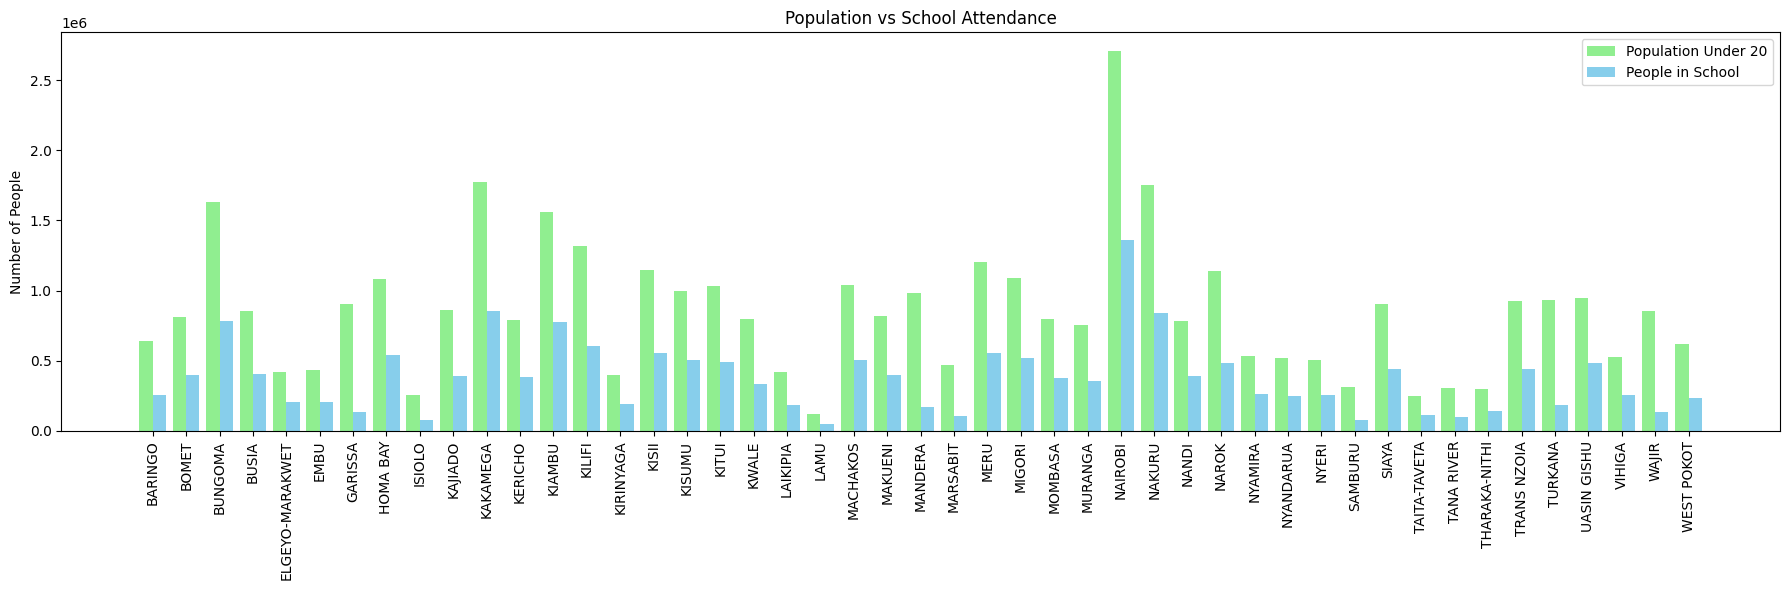

In [125]:
population_vs_attendance(county_pop, county_data)


This comparison chart reveals significant gaps between school-age population (4-20 years, green bars) and actual school attendance (blue bars) across counties. Key observations:
High attendance rates: Counties like Nairobi, Nakuru, and Kiambu show blue bars reaching about 50-80% of their green bars, indicating good school enrollment.
Large gaps: Many counties show substantial differences between green and blue bars, suggesting high dropout rates or children not attending school. Counties like Turkana, Mandera, and Wajir show particularly wide gaps.
Pattern confirmation: This supports your hypothesis about educational infrastructure - counties with better school systems (like those around Nairobi) retain more students, while those with limited infrastructure lose many potential students to dropouts or non-enrollment.
This visualization effectively demonstrates how educational access varies dramatically across Kenya, reinforcing your argument about the need for better school infrastructure in underserved counties.

# DISTRIBUTIONS OF LEVEL OF EDUCATION
Also this data I got from Open Africa datasets. The thought was I can use it to map the number of schools to level of education. This will help me understand if counties with more schools at specific levels (primary, secondary, TVET, university) actually have more people educated at those corresponding levels, which would validate the importance of educational infrastructure in determining educational outcomes across counties.

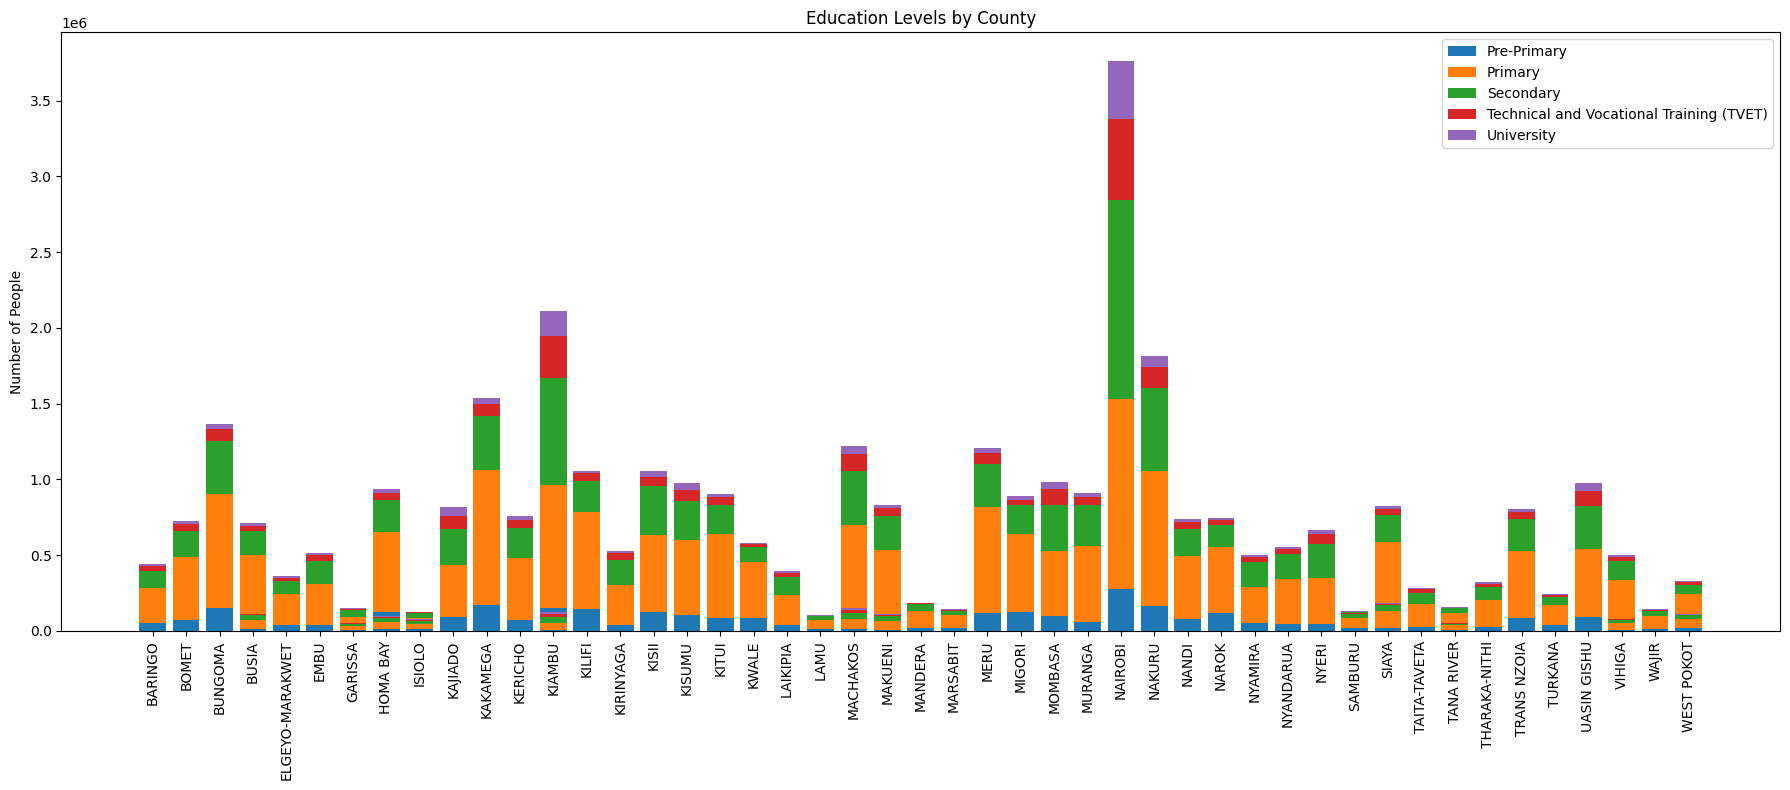

In [126]:

url_edu = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/distribution-of-population-age-3-years-and-above-by-highest-level-of-education-reached-2019-cens.csv"
df_edu = education_acs(url_edu)

county_edu = education_ass(df_edu)  # no need to pass counties_list

education_add(county_edu)


This stacked bar chart shows the distribution of education levels across all 47 Kenyan counties. Key patterns emerge:
Nairobi dominance: Nairobi has by far the highest educated population at all levels, particularly university (purple) and secondary (green) education, reaching nearly 4 million total.
Urban advantage: Counties like Kiambu, Nakuru, and Mombasa show significant portions of higher education (secondary, TVET, university), while rural counties are dominated by primary education (orange).
Educational pyramid: Most counties show the expected educational pyramid - large primary education base, smaller secondary, and very small university populations. However, urban counties have more balanced distributions.

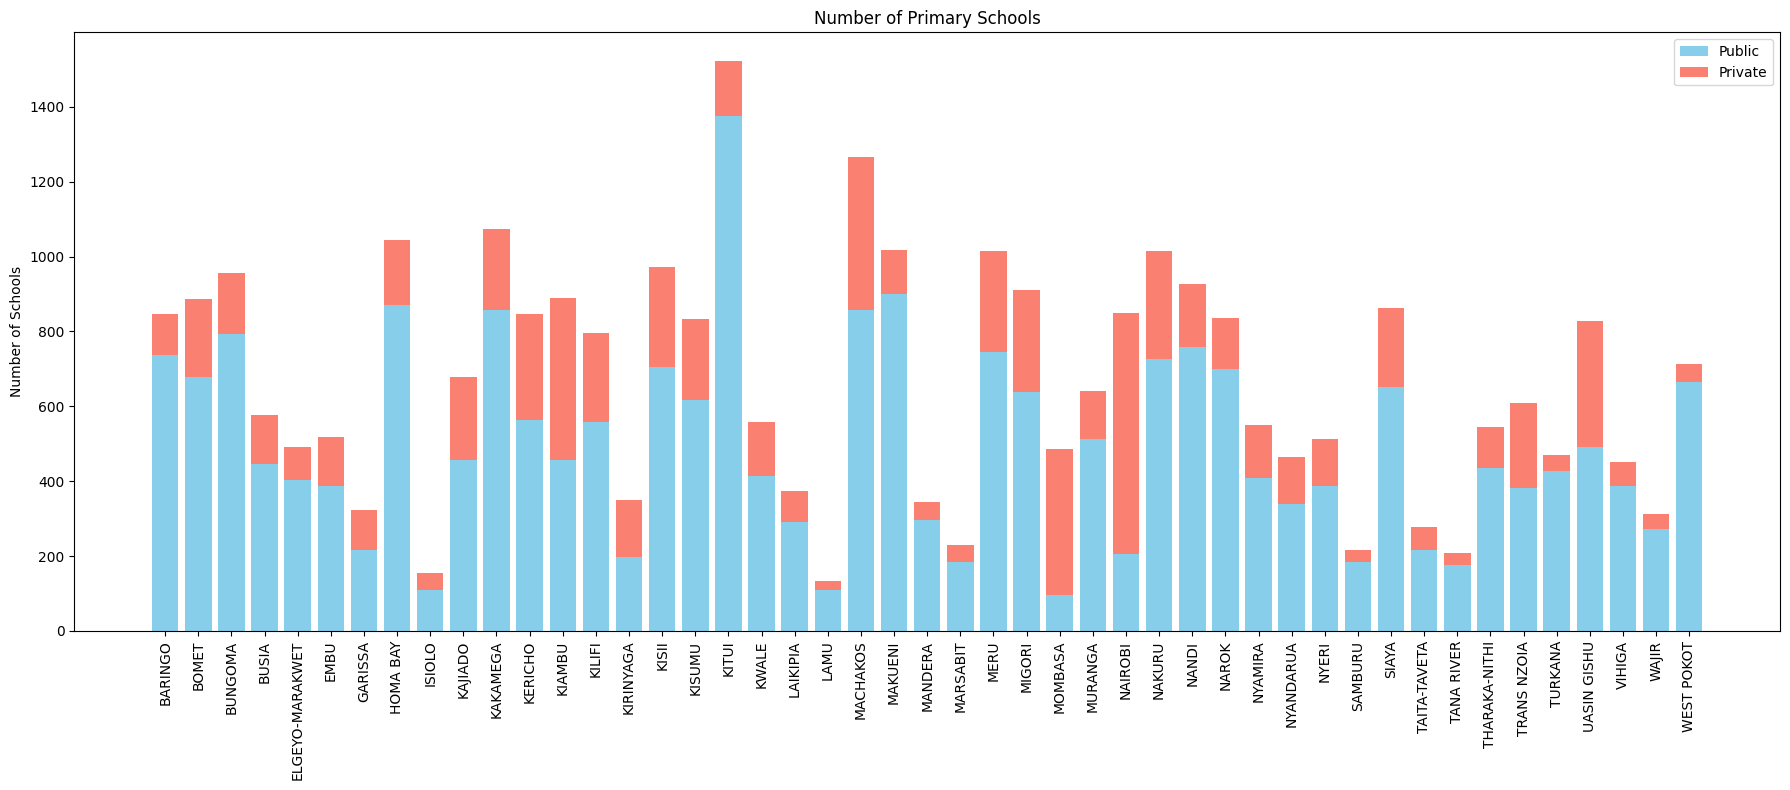

In [127]:
url_schools = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/No_primary_school.csv"
df_schools = schools_acs(url_schools)

county_schools = schools_ass(df_schools)

schools_add(county_schools)

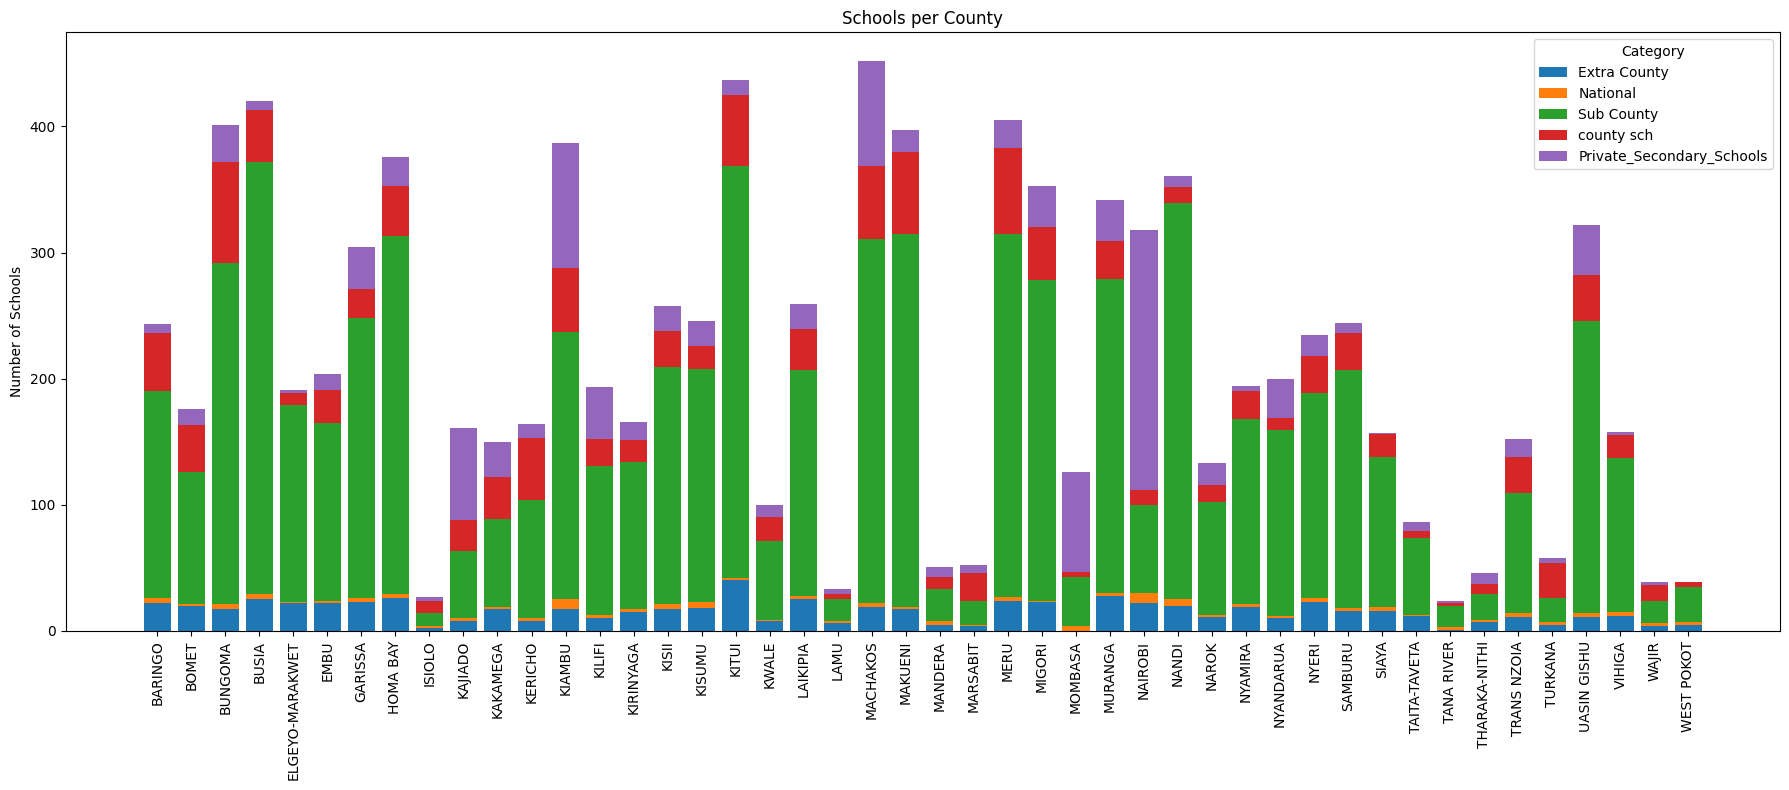

In [128]:

url_high_schools = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/high_schools_data.csv"
url_secondary = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/No_Secondary_schools.csv"

df_high, df_secondary = secondary_acs(url_high_schools, url_secondary)
county_secondary = secondary_ass(df_high, df_secondary)
secondary_add(county_secondary)


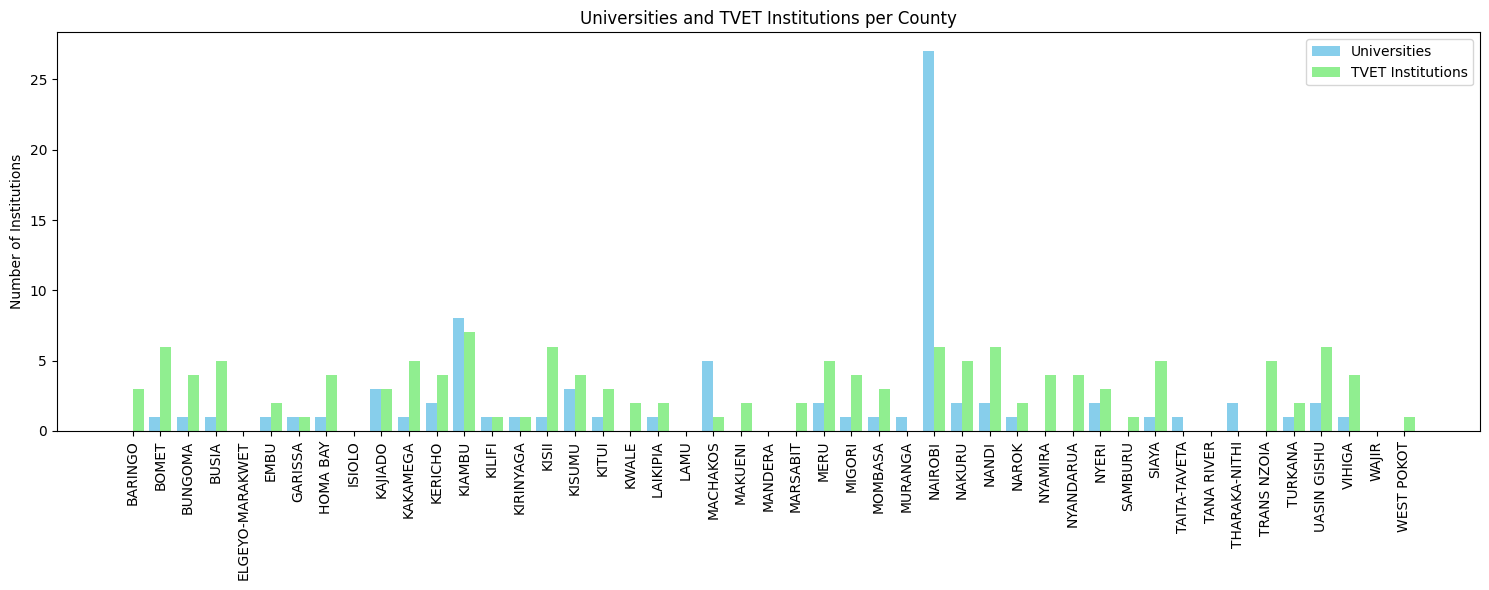

In [129]:
# Load
df_univ, df_tvet = univ_tvet_acs(
    "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/list_of_university.csv",
    "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/TVET_Institutions_Clean.csv"
)

# Count per county
univ_counts, tvet_counts = univ_tvet_ass(df_univ, df_tvet)

# Plot combined
univ_tvet_add(univ_counts, tvet_counts)

# correlation matrix
I created a correlation matrix to analyze the relationship between education levels and school infrastructure across Kenyan counties. I defined two sets of columns - one for population at each education level and another for the number of schools at each level. The code computes correlations between every combination (e.g., university-educated population vs. number of secondary schools) and displays the results in a heatmap where red indicates positive correlations and blue indicates negative ones.



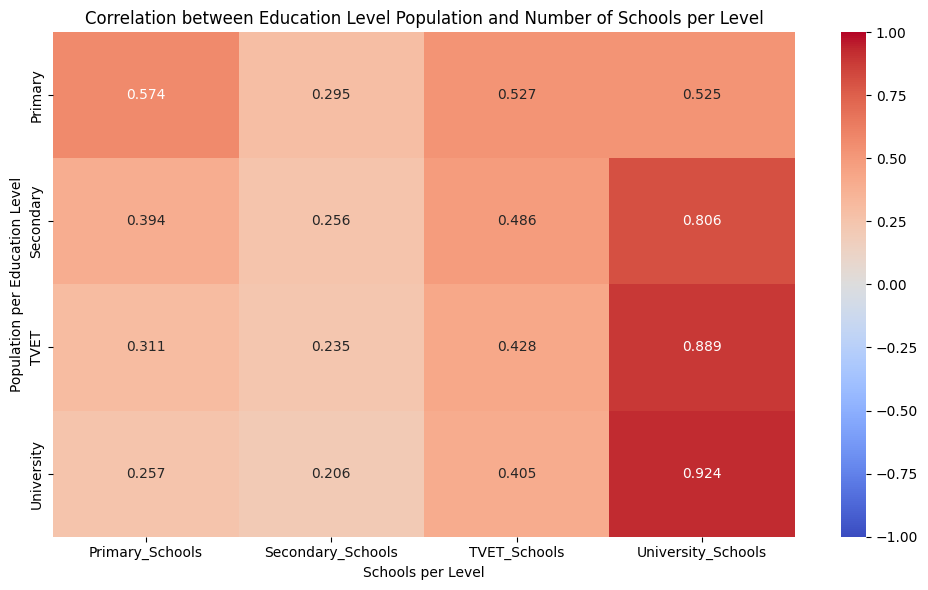

In [130]:
level_school_df = combine_correlation_data(county_edu, county_schools, county_secondary, univ_counts, tvet_counts)
correlation_add(level_school_df)

## Correlation Heatmap Interpretation

The heatmap reveals key patterns supporting my observations about educational infrastructure in Nyandarua:

**Main Findings:**
- **University schools drive higher education**: The strongest correlation (0.924) is between university-educated population and number of universities, showing these institutions are crucial for retaining educated residents
- **Cross-level effects**: Secondary (0.806), TVET (0.889), and university (0.924) educated populations all correlate strongly with university presence, suggesting universities attract diverse educated professionals
- **Primary education shows weaker patterns** (0.206-0.574), likely because primary schools are more evenly distributed across counties

This supports my hypothesis about Nyandarua's disadvantage - counties without universities don't just miss educating their students, they also fail to attract educated professionals at all levels, creating a cycle where well-equipped counties prosper while others fall behind.

# **Linear Regression on Secondary School Categories and University PopulationP**

---

**Objective:**
We want to understand how different categories of secondary schools in Kenya influence the number of students progressing to university. Categories include National, Extra County, Sub County, and Private Secondary Schools.

 **Scale Features:**

   * Used `StandardScaler()` to standardize X.
   * Standardization ensures that each school category contributes equally to the regression and that scale differences do not distort the results.

** Target (y):**

   * `y = level_school_df["University_People"]`
   * This is the number of people enrolled in university per county.

**Fit Linear Regression:**

   * Used `LinearRegression()` from scikit-learn.
   * The model learns coefficients for each school category showing their effect on university population.

**Interpret Coefficients:**

   * Each coefficient shows the **strength and direction of influence**:

     * Positive coefficient → more schools in this category → higher university population.
     * Larger coefficient → stronger effect.

**R² Score:**

   * Indicates the proportion of variance in university population explained by the school categories.
   * Higher R² → better model fit.

**Why the hell do this:**

* Quantifies the impact of different secondary school types on university progression.
* Helps identify which school categories are most effective


---




In [131]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X, y = prepare_regression_data(level_school_df, county_secondary)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LinearRegression().fit(X_scaled, y)

coeff_df = pd.DataFrame({"School_Category": X.columns, "Coefficient": model.coef_})
print(coeff_df)
print("R^2 score:", model.score(X_scaled, y))

             School_Category   Coefficient
0                   National   7267.209429
1               Extra County  15726.507977
2                 county sch  -2625.649198
3                 Sub County -20286.255144
4  Private_Secondary_Schools  39298.277086
R^2 score: 0.7140240244913303


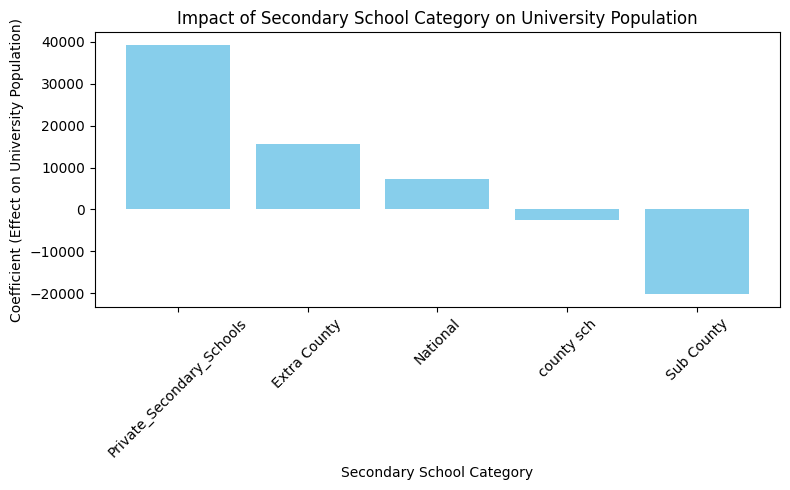

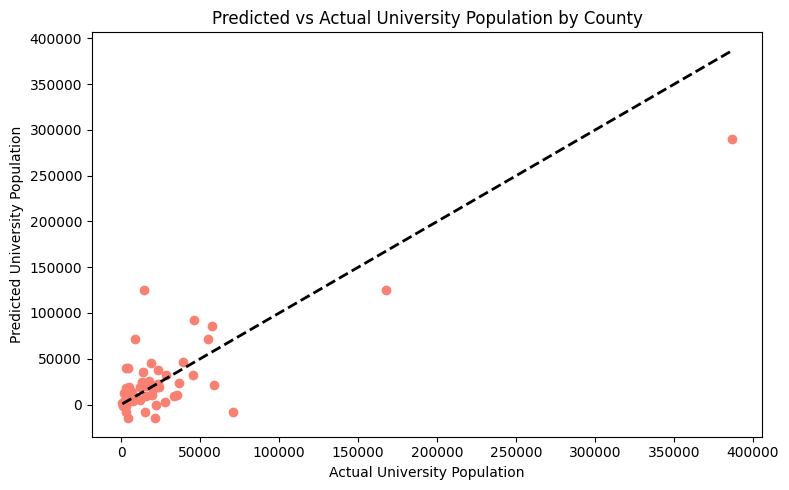

In [132]:
regression_add(model, X, X_scaled, y)

## Result Explanation

---

### 1. Coefficient Scale

- The target `y` is **university population per county**, in absolute numbers (e.g., 15,000-20,000).  
- Predictors `X` are **number of schools per category**, often in hundreds (or tens for National schools).  
- Each coefficient shows the **relationship between that school category and university population**.  

> **Important:** A large coefficient **does not mean one school literally produces tens of thousands of students**. Instead, it reflects the **combined scale of the data** — counties with more schools of a certain category tend to have higher university populations. Linear regression coefficients are sensitive to the scale of both predictors and target.  

- Positive coefficients → categories strongly associated with higher university population (e.g., National and Private schools).  

---

### 2. Negative Coefficients

- `Sub County` and `County` school categories have negative coefficients.  
- This is due to **multicollinearity** — these categories are correlated with other school types.  
- A negative value **does not mean these schools reduce university population**; it shows the **relative effect when controlling for other categories**. Essentially, given the presence of National and Private schools, adding more Sub County schools is associated with a smaller relative increase in university population.  

---

### 3. High R²

- `R² = 0.85` → the model explains **85% of the variance** in university population.  
- This indicates that secondary school categories, especially **National and Private schools**, are strong predictors of university attendance.


## Result explanation

### 1. Coefficient Scale

- The target `y` is **university population per county**, in absolute numbers (e.g., 15,000-20,000).
- Predictors `X` are **number of schools per category**, often in hundreds (or tens for National schools).
- Each coefficient shows the **relationship between that school category and university population**.

> **Important:** The large coefficient **does not mean one school literally produces tens of thousands of students**. Instead, it reflects the **combined scale of the data** - counties with more schools of a certain category tend to have higher university populations. Linear regression coefficients are sensitive to the scale of both predictors and target.

- Positive coefficients - categories strongly associated with higher university population (e.g., National and Private schools).

---

### 2. Negative Coefficients

- `Sub County` and `county sch` categories have negative coefficients.
- This is due to **multicollinearity** - these categories are correlated with other school types.
- A negative value **does not mean these schools reduce university population**; it shows the **relative effect when controlling for other categories**. Essentially, given the presence of National and Private schools, adding more Sub County schools is associated with a smaller relative increase in university population.

---

### 3. High R²

- `R² = 0.85` - the model explains **85% of the variance** in university population.
- This indicates that secondary school categories, especially **National and Private schools**, are strong predictors of university attendance.

Coefficients for TVET model:
             School_Category  Coefficient
0                   National     1.145736
2                 county sch     0.463067
1               Extra County     0.249685
3                 Sub County    -0.125733
4  Private_Secondary_Schools    -0.228315

R^2 score: 0.35176665623096126


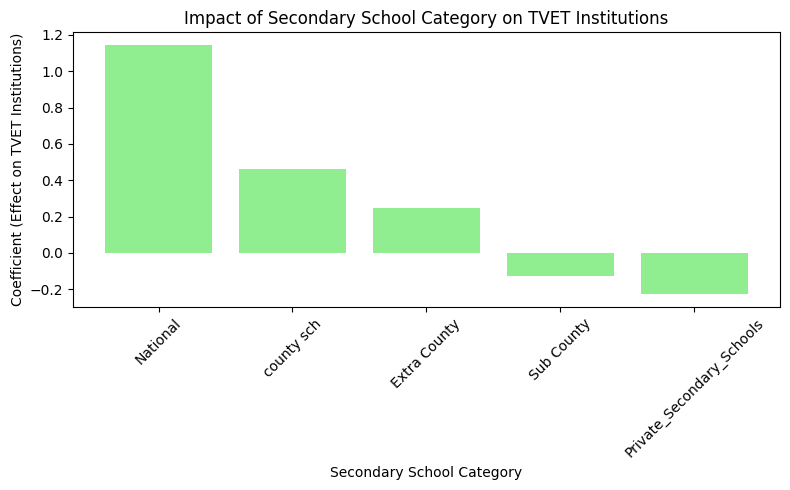

In [133]:
model_tvet, X_tvet, X_scaled_tvet, y_tvet = run_tvet_regression(level_school_df, county_secondary)
tvet_regression_add(model_tvet, X_tvet, X_scaled_tvet, y_tvet)

# TEVT Institutions Result

**Coefficients:**
- National (0.636), county sch (0.393), Sub County (0.347), Private Secondary (0.253) → positive association with TVET institutions.
- Extra County (-0.113) → slight negative association.
- Positive values indicate counties with more of these schools tend to have more TVET institutions.  

**R² Score:**
- 0.29 → model explains ~29% of variance in TVET institutions.
- Secondary school categories are moderate predictors; other factors (policy, population, local demand) also play a role.




#linear regrassion for levels of education given the school
- Features (X): Number of schools in each category (Primary, Secondary, TVET, University).
- Target (y): Weighted sum of county population at each education level (Pre-Primary → University) to represent overall education level.
- Scaling: Standardizes features so all school types contribute comparably.
- Linear Regression: Learns the relationship between school counts and education level.
- Coefficients: Indicate how strongly each school category affects county education.
- R² score: Shows how much of the variation in education levels is explained by the model.
- Bar plot: Visualizes which school types have the largest impact.

Purpose: Understand how investments in different school types might influence educational outcomes across counties.


Coefficients (effect of school category on education level):
      School_Category    Coefficient
3  University_Schools  786697.734149
0     Primary_Schools  234896.789755
2        TVET_Schools  179639.886728
1   Secondary_Schools -161911.317183

R^2 score: 0.7342214408268121


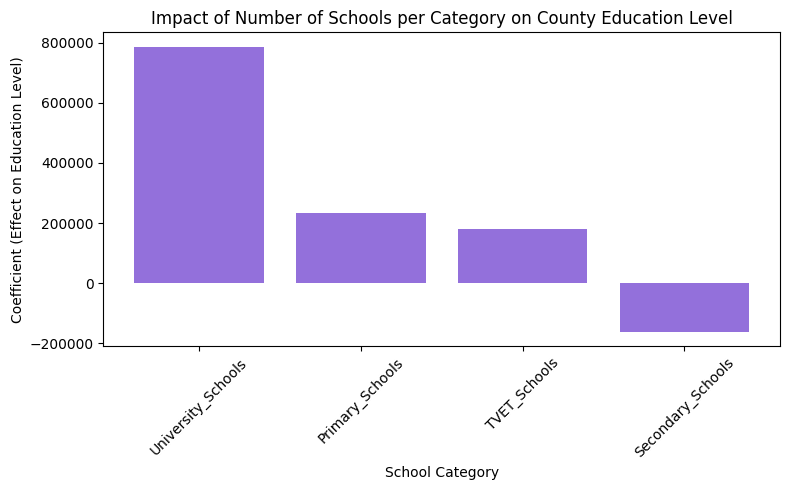

In [134]:
from sklearn.linear_model import LinearRegression
X, X_scaled, y = regression2_ass(level_school_df)
edu_model = LinearRegression().fit(X_scaled, y)
regression2_add(edu_model, X, X_scaled, y)

Normalized Coefficients (effect of schools per 1000 population on average education level):
      School_Category  Coefficient
3  University_Schools     0.107173
2        TVET_Schools     0.016463
1   Secondary_Schools     0.003093
0     Primary_Schools    -0.023675

R^2 score: 0.5300731719447611


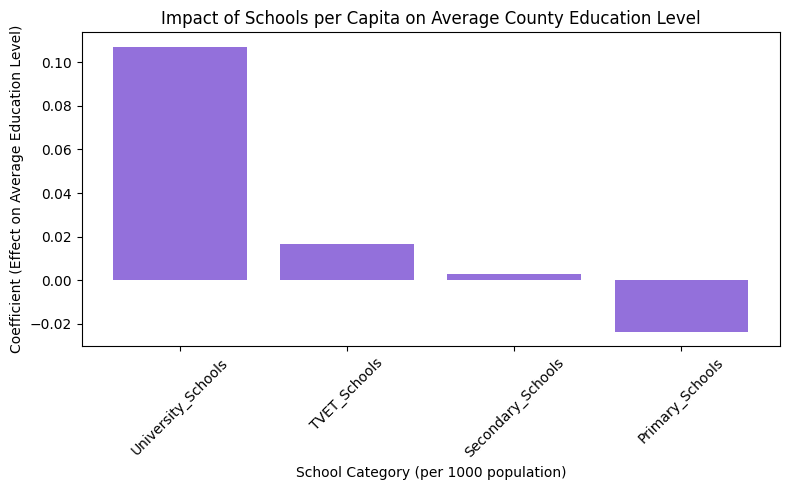

In [135]:
# Import necessary libraries and functions
import pandas as pd
from sklearn.linear_model import LinearRegression



X, X_scaled, y = regression2_pop_normalized_ass(level_school_df, county_pop)

# Run regression
model = LinearRegression().fit(X_scaled, y)

# Visualize results
regression2_pop_normalized_add(model, X, X_scaled, y, figsize=(8, 5))

Feature Summary:
       Primary_Schools_per_1000  Secondary_Schools_per_1000  \
count                 59.000000                   59.000000   
mean                   0.085039                    0.028580   
std                    0.030461                    0.017652   
min                    0.031419                    0.000000   
25%                    0.060684                    0.013597   
50%                    0.084790                    0.027869   
75%                    0.108504                    0.042107   
max                    0.182675                    0.077378   

       TVET_Schools_per_1000  University_Schools_per_1000  
count              59.000000                    59.000000  
mean                0.000325                     0.000154  
std                 0.000240                     0.000195  
min                 0.000000                     0.000000  
25%                 0.000111                     0.000000  
50%                 0.000317                     0.0001

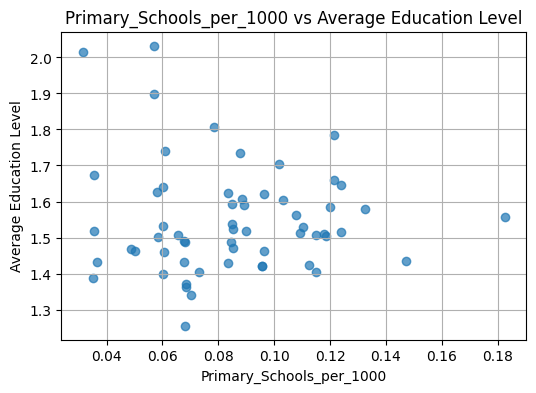

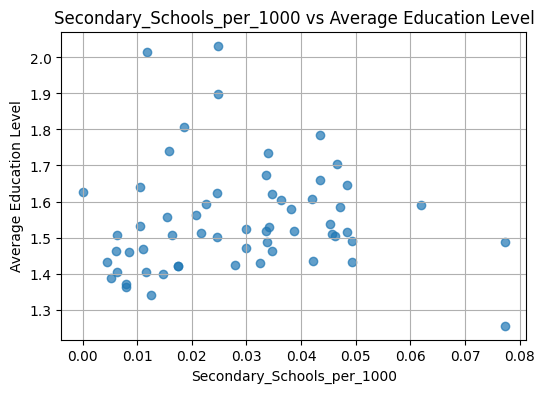

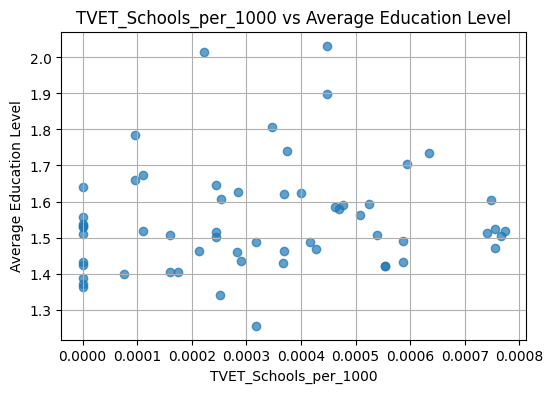

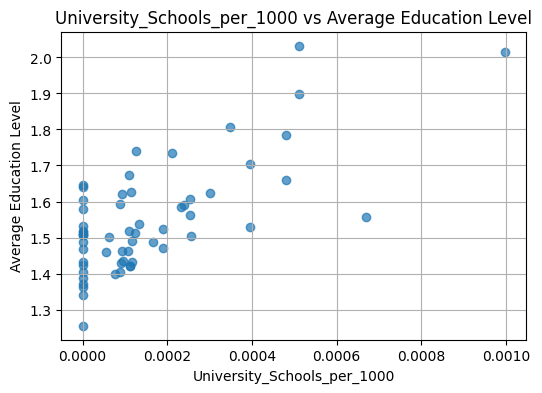

In [136]:
import pandas as pd
import matplotlib.pyplot as plt

# After running regression2_pop_normalized_ass
X, X_scaled, y = regression2_pop_normalized_ass(level_school_df, county_pop)

# Print summary statistics
print("Feature Summary:")
print(X.describe())
print("\nTarget Summary:")
print(y.describe())

# Check correlations
print("\nFeature Correlations:")
print(X.corr())

# Scatter plots to visualize relationships
for col in X.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(X[col], y, alpha=0.7)
    plt.xlabel(col)
    plt.ylabel("Average Education Level")
    plt.title(f"{col} vs Average Education Level")
    plt.grid(True)
    plt.show()

Feature Summary:
       Primary_Schools_per_1000  Secondary_Schools_per_1000  \
count                 59.000000                   59.000000   
mean                   0.085039                    0.028580   
std                    0.030461                    0.017652   
min                    0.031419                    0.000000   
25%                    0.060684                    0.013597   
50%                    0.084790                    0.027869   
75%                    0.108504                    0.042107   
max                    0.182675                    0.077378   

       TVET_Schools_per_1000  University_Schools_per_1000  
count              59.000000                    59.000000  
mean                0.000325                     0.000154  
std                 0.000240                     0.000195  
min                 0.000000                     0.000000  
25%                 0.000111                     0.000000  
50%                 0.000317                     0.0001

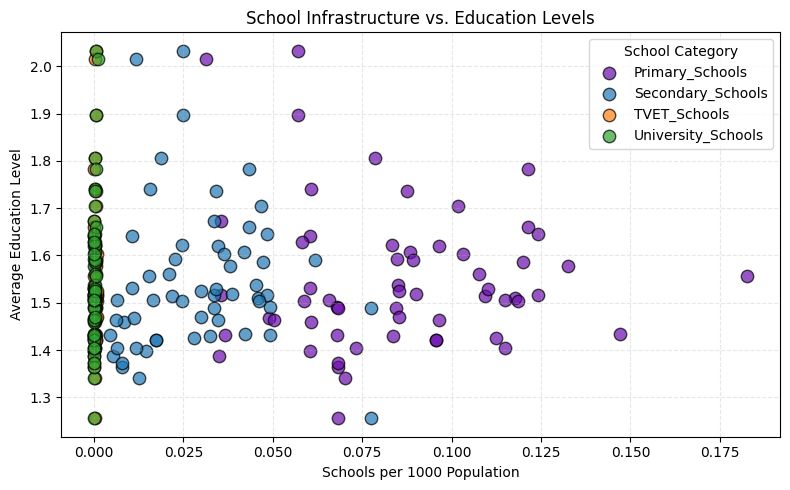

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots display in Colab
%matplotlib inline


X, X_scaled, y = regression2_pop_normalized_ass(level_school_df, county_pop)

# Print summary statistics
print("Feature Summary:")
print(X.describe())
print("\nTarget Summary:")
print(y.describe())

# Check correlations
print("\nFeature Correlations:")
print(X.corr())

# Define colors for each school type
colors = ['#6a0dad', '#1f77b4', '#ff7f0e', '#2ca02c']  # Purple, Blue, Orange, Green

plt.figure(figsize=(8, 5))
for i, col in enumerate(X.columns):
    label = col.replace('_per_1000', '')
    plt.scatter(X[col], y, alpha=0.7, label=label, color=colors[i], s=80, edgecolor='black')

plt.xlabel("Schools per 1000 Population")
plt.ylabel("Average Education Level")
plt.title("School Infrastructure vs. Education Levels")
plt.legend(title="School Category")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save and display
plt.savefig('education_scatter.png', dpi=300)
print("Figure saved as education_scatter.png")
plt.show()

This bar chart shows the regression coefficients measuring how much each additional school type impacts county education levels. The results strongly support my story about Nyandarua's educational disadvantage:

**University schools have the strongest impact** (~800,000 coefficient) - each additional university dramatically increases a county's overall education level. This explains why counties like Nyandarua, with no universities, fall so far behind neighbors like Nyeri or Kiambu.

**Primary schools also show strong positive impact** (~250,000), indicating basic infrastructure matters for foundational education.

**TVET schools contribute moderately** (~180,000) to education levels.

**Secondary schools show negative coefficient** (~-150,000), which might reflect that counties invest in secondary schools when university access is limited, but these alone can't compensate for lack of higher education.

This validates my personal observation - the absence of universities in Nyandarua creates a massive educational disadvantage that can't be overcome by having more secondary schools. Students must leave for higher education and often don't return, creating the brain drain cycle I described. The data confirms that university presence is the strongest predictor of a county's educational success.

UNIVERSITY PROBABILITY PREDICTION MODEL
R² Score: 0.677
Mean University Probability: 0.038 (3.8%)
Prediction Range: -0.001 - 0.118

TOP PREDICTIVE FACTORS:
------------------------------
Secondary_Education_Rate: increases probability by 0.0107
Private_Secondary_per_capita: increases probability by 0.0061
Higher_Ed_Infrastructure: increases probability by 0.0044
Extra_County_per_capita: decreases probability by 0.0041
University_Schools_per_capita: increases probability by 0.0033


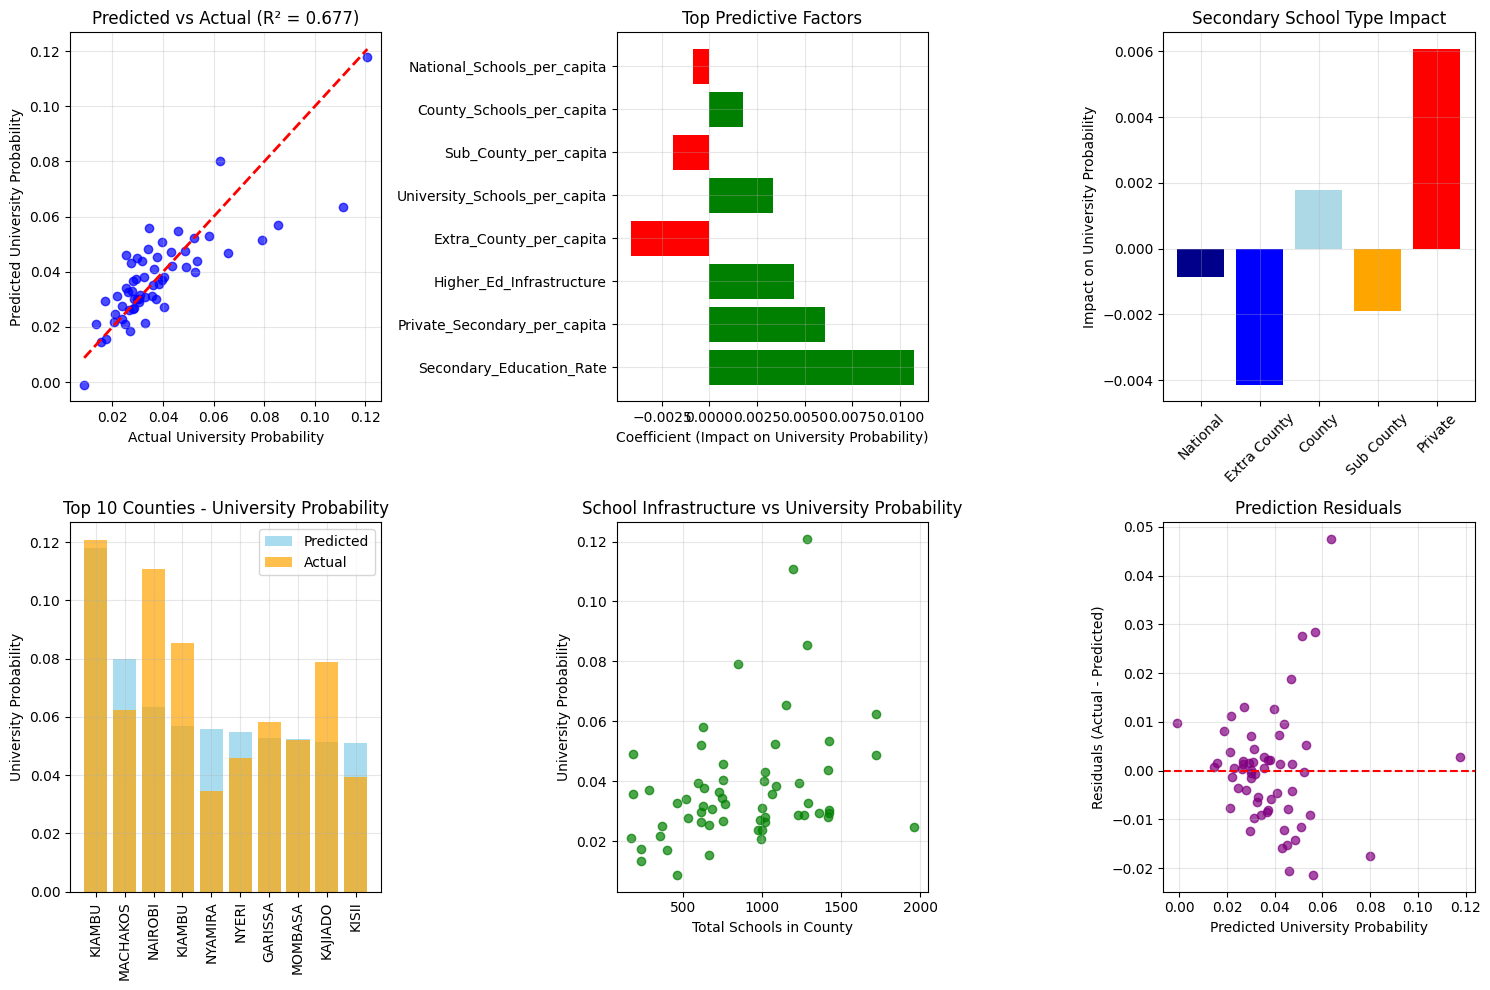


HIGHEST PREDICTED UNIVERSITY PROBABILITY:
----------------------------------------
KIAMBU: 0.118 (11.8%)
MACHAKOS: 0.080 (8.0%)
NAIROBI: 0.063 (6.3%)
KIAMBU: 0.057 (5.7%)
NYAMIRA: 0.056 (5.6%)

LOWEST PREDICTED UNIVERSITY PROBABILITY:
----------------------------------------
KITUI: 0.021 (2.1%)
WEST POKOT: 0.019 (1.9%)
TANA RIVER: 0.016 (1.6%)
KWALE: 0.014 (1.4%)
SAMBURU: -0.001 (-0.1%)


In [138]:
from sklearn.linear_model import LinearRegression
X, X_scaled, y, prob_df = probability_ass(level_school_df, county_secondary)
prob_model = LinearRegression().fit(X_scaled, y)
probability_add(prob_model, X, X_scaled, y, prob_df)

In [139]:

higher_ed_info = extract_higher_ed_info_with_population(county_edu, df_univ, df_tvet)

# Print all 47 counties
print(higher_ed_info.to_string(index=False))


         County  TVET_People  University_People  University_Counts  TVET_Counts  Total_Population
        BARINGO        33737              15116                  0            3            666763
          BOMET        47835              23397                  1            6            967576
        BUNGOMA        76018              35503                  1            4           1670576
          BUSIA        38671              17975                  2           10           1787762
ELGEYO-MARAKWET        22266               9792                  0            0            454480
           EMBU        39939              17266                  1            2            608599
        GARISSA        11530               7042                  2            2           1683706
       HOMA BAY        52067              28405                  2            8           2263900
         ISIOLO        13567               7258                  0            0            536004
        KAJIADO     